In [134]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('../'))
from src.operations import parity_operator, global_rotation
from src.spin import Spin

In [210]:
omega_q = 2e2
omega_x = 2*np.pi * 5e4

T = 70e-6

t_free = T/6
t_drive = T/3

In [211]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()
y_2 = global_rotation(nucleus.I, np.pi/2, axis='y')
_y_2 = global_rotation(nucleus.I, -np.pi/2, axis='y')
Hq = omega_q * Iz * Iz
H_x  = Hq + omega_x * Ix
_H_x = Hq - omega_x * Ix

In [216]:
U_free  = qt.propagator(Hq,  t_free)
U_x     = qt.propagator(H_x,  t_drive)
U_xm    = qt.propagator(_H_x, t_drive)
U_total = U_free * Y2 * U_x * U_xm * Y2m * U_free

In [217]:
U_total

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 9.97279411e-01-7.34304714e-02j -7.41439361e-16-4.46170094e-16j
   2.08891659e-03-1.42042599e-03j -2.38241226e-16-3.18304726e-16j
   2.31433641e-06-4.88470342e-06j  1.05326565e-15-6.60909156e-16j
  -6.43130908e-10-6.66036214e-09j  3.37115800e-18+1.17912907e-16j]
 [ 3.03504095e-16-1.09344291e-16j  9.97291522e-01-7.34329306e-02j
  -4.10716962e-16-3.24581692e-16j  3.05828447e-03-2.07935885e-03j
   5.04193447e-17+5.17898360e-17j  3.38853415e-06-7.15104286e-06j
  -2.20452531e-16+1.10779402e-16j -6.43129040e-10-6.66036226e-09j]
 [-2.27443683e-03-1.09914436e-03j  3.86308994e-16-8.19190411e-17j
   9.97287730e-01-7.34329304e-02j  3.53855537e-16-4.02392941e-17j
   3.53162946e-03-2.40106948e-03j  6.94537996e-17+1.05774297e-15j
   3.38853415e-06-7.15104286e-06j  1.66536362e-16-1.76785884e-16j]
 [-1.23036059e-16-5.97411356e-16j -3.32986635e-03-1.60898336e-03j
   2.93038324e-16-1.35296072e-16j  9.9728

In [219]:
U_bare = qt.propagator(Hq,  t_free*6)
U_bare

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.98532806-0.17065918j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.99617366-0.0873882j  0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.99950382-0.03149478j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.99999387-0.00349999j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.99999387-0.00349999j 0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j   

In [227]:
rotary_fidelity = qt.process_fidelity(U_total, qt.qeye(nucleus.dim))
rotary_fidelity

0.9999710821703862

In [ ]:
bare_fidelity = qt.process_fidelity(U_bare, qt.qeye(nucleus.dim))
bare_fidelity

0.9958893790494346

In [356]:
# iterate over Iz rotation strengths and plot fidelity
omega_qs = np.linspace(0, 10000, 100)
bare_fidelities = np.zeros(len(omega_qs))
rotary_fidelities = np.zeros(len(omega_qs))
rotary_fidelities_symmetrized = np.zeros(len(omega_qs))

omega_x = 2*np.pi * 5e4
T = 70e-6
t_free = T/6
t_drive = T/3

for i, omega_q in enumerate(omega_qs):
    Hq = omega_q * Iz * Iz
    H_x  = Hq + omega_x * Ix
    _H_x = Hq - omega_x * Ix
    U_free  = qt.propagator(Hq,  t_free)
    U_x     = qt.propagator(H_x,  t_drive)
    U_xm    = qt.propagator(_H_x, t_drive)
    U_total_symmetrized = U_free * Y2 * U_x * U_xm * Y2m * U_free
    U_total = Y2 * U_x * U_xm * Y2m * U_free * U_free
    U_bare = qt.propagator(Hq,  t_free*6)
    rotary_fidelities[i] = qt.process_fidelity(U_total, qt.qeye(nucleus.dim))
    rotary_fidelities_symmetrized[i] = qt.process_fidelity(U_total_symmetrized, qt.qeye(nucleus.dim))
    bare_fidelities[i] = qt.process_fidelity(U_bare, qt.qeye(nucleus.dim))

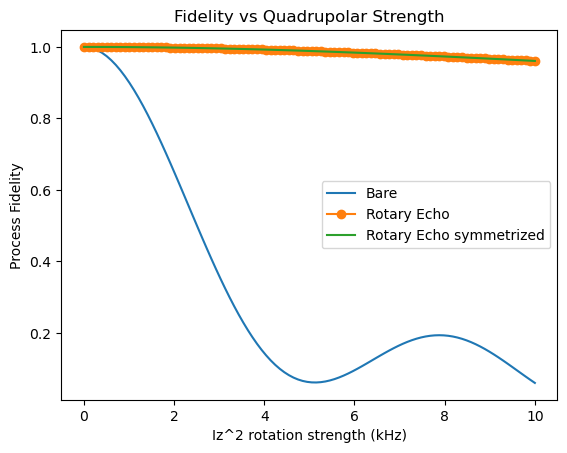

In [357]:
plt.plot(omega_qs/1e3, bare_fidelities, label='Bare')
plt.plot(omega_qs/1e3, rotary_fidelities, label='Rotary Echo', marker='o')
plt.plot(omega_qs/1e3, rotary_fidelities_symmetrized, label='Rotary Echo symmetrized')
plt.xlabel('Iz^2 rotation strength (kHz)')
plt.ylabel('Process Fidelity')
plt.title('Fidelity vs Quadrupolar Strength')
plt.legend()

# spin locking

In [354]:
# iterate over Iz rotation strengths and plot fidelity
omega_qs = np.linspace(0, 1000, 100)
bare_fidelities = np.zeros(len(omega_qs))
locking_fidelities = np.zeros(len(omega_qs))

omega_x = 2*np.pi * 5e4
T = 70e-6
t_free = T/6
t_drive = T/3


for i, omega_q in enumerate(omega_qs):
    Hz = omega_q * Iz
    H_x  = Hz + omega_x * Ix
    _H_x = Hz - omega_x * Ix
    U_free  = qt.propagator(Hz,  t_free)
    U_x     = qt.propagator(H_x,  t_drive)
    U_xm    = qt.propagator(_H_x, t_drive)
    U_total = U_x * U_xm
    U_bare = qt.propagator(Hz,  t_free*6)
    locking_fidelities[i] = qt.process_fidelity(U_total, qt.qeye(nucleus.dim))
    bare_fidelities[i] = qt.process_fidelity(U_bare, qt.qeye(nucleus.dim))

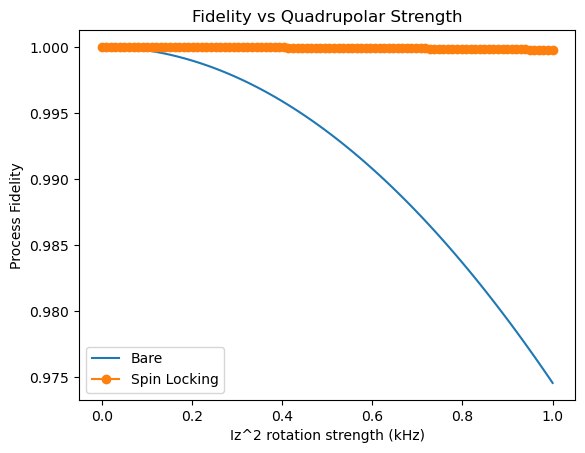

In [355]:
plt.plot(omega_qs/1e3, bare_fidelities, label='Bare')
plt.plot(omega_qs/1e3, locking_fidelities, label='Spin Locking', marker='o')
plt.xlabel('Iz^2 rotation strength (kHz)')
plt.ylabel('Process Fidelity')
plt.title('Fidelity vs Quadrupolar Strength')
plt.legend()